### LLM Architecture

In [1]:
#GPT configs to be used later
GPT_CONFIG_124M = {
    "vocab_size" : 50257, #GPT-2's vocab size (to be used by BPE tokenizer)
    "context_length": 1024, #max number of tokens, # of position vectors 
    "emb_dim": 768, #embedding dimension 
    "num_heads": 12, #number of attention heads, like different attention mechanisms analyzed 
    "num_layers": 12, #transformer blocks(will learn)
    "drop_rate": 0.1, #drop 10% randomly during training to prevent overfitting
    "qkv_bias": False, #whether to include bias(will learn more too)
}

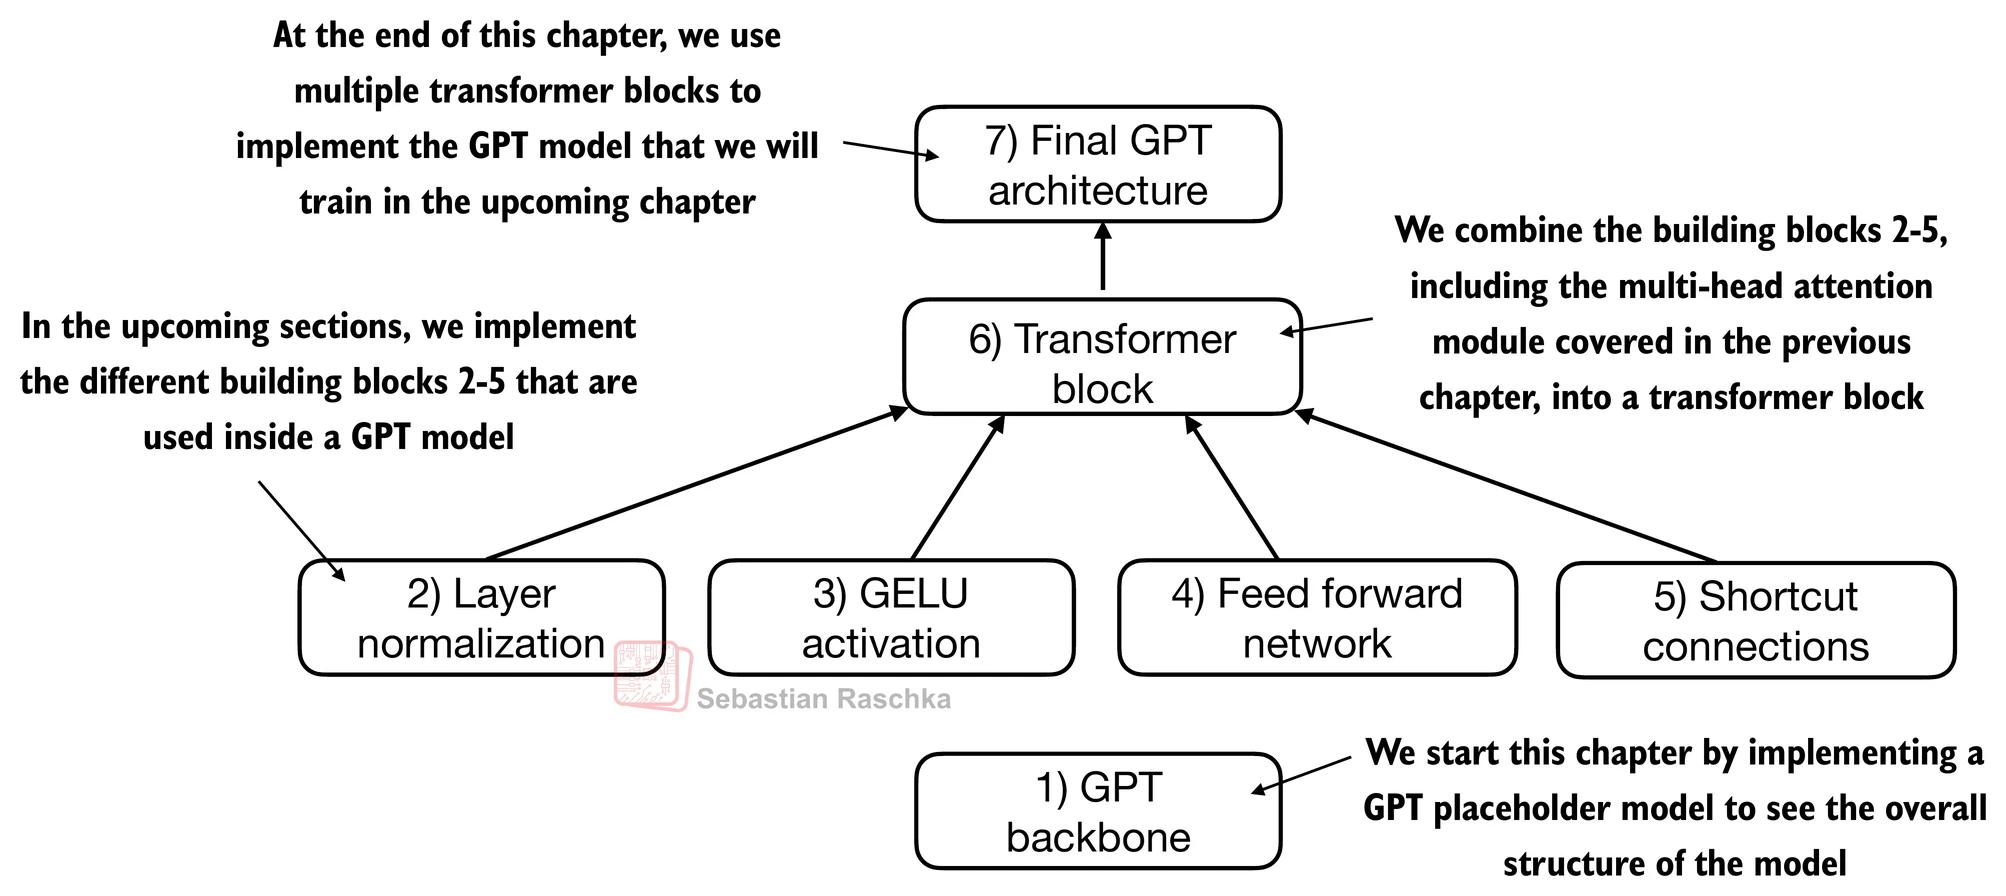


## **Prepare Data** 
- tokenize (tiktoken)
- turn to tensor (torch.tensor)


In [2]:
import tiktoken 
import torch
import torch.nn as nn

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

#tokenize text then convert to tensor and stack them to create input data
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [3]:
torch.manual_seed(123)
from GPT_Model_architecture_class import DummyGPTmodel

model = DummyGPTmodel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


[2,4,50257]

2-> batch size, # of rows/samples (txt1, txt2)
4 -> length per sample (4 words)
50257 -> number of unique words/subwords that GPT2 tokenizer has 

## **Normalizing activations with layer normalization**
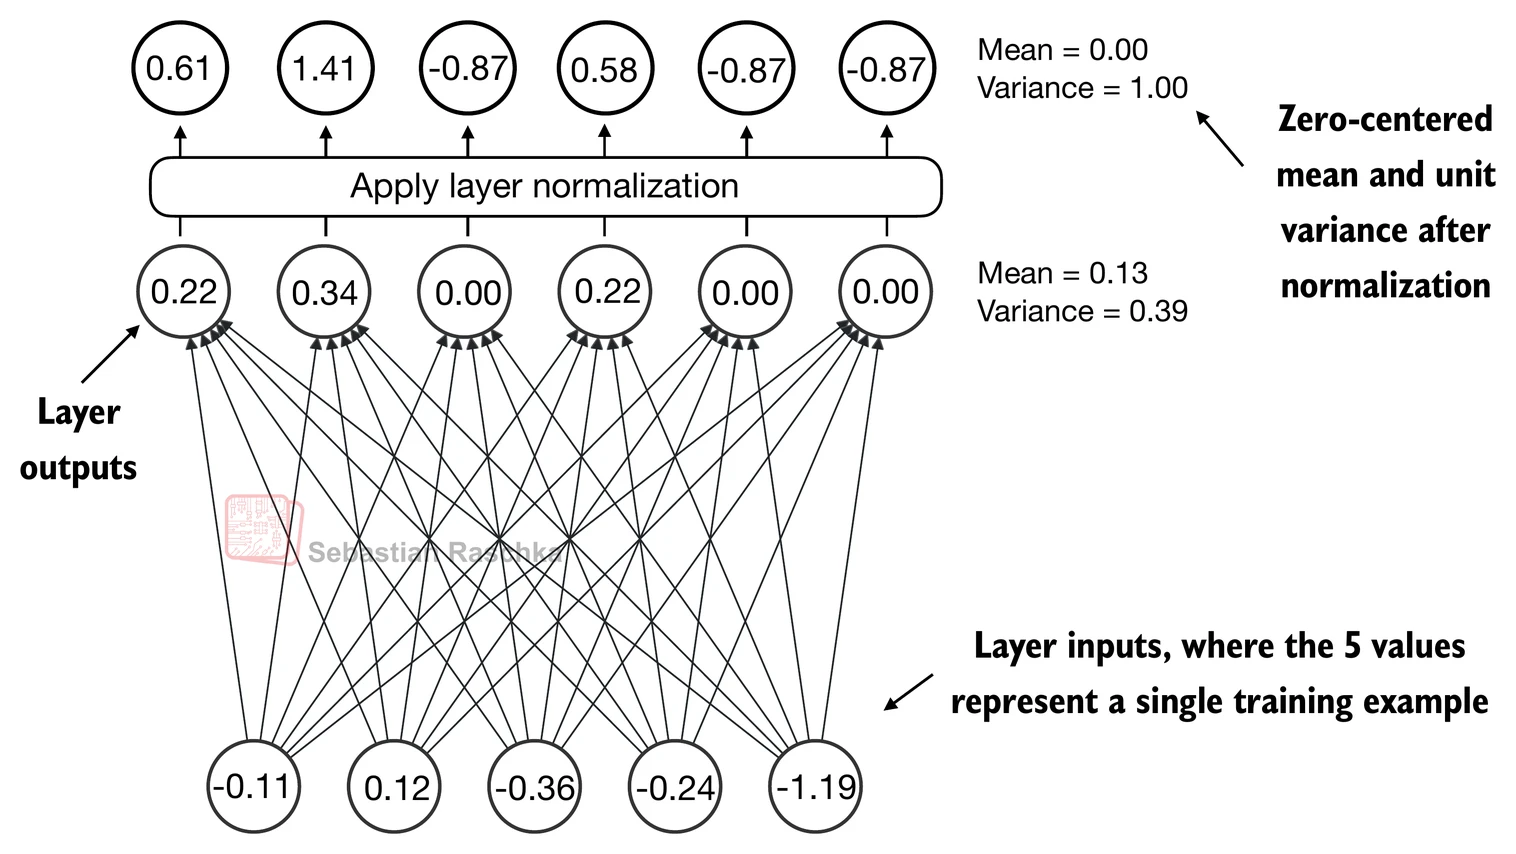

In [4]:
torch.manual_seed(123)

batch_example = torch.randn(2,5)
print(batch_example) #2 samples, 5 features each


layer = nn.Sequential( #sequential container to stack layers together
    nn.Linear(5,6),  #5 input features, 6 output features #linear transformation of the input data
    nn.ReLU() #filter, activation function only allow positive values through
)
out = layer(batch_example)
print(out) #output of the sequential layer, 2 samples, 6 features each

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [5]:
#look at the current mean and variance of the output

mean = out.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out.var(dim=-1, keepdim=True) #variance across features for each sample
print("Mean before normalization:", mean)
print("Variance before normalization:", var)


Mean before normalization: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance before normalization: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


why dim = -1

When data becomes multi-dimensional : (batch_size, num_tokens, emb_size)
we want to calculate mean and variance across the embedding dimension (features) for each token in each sample.
dim=-1 means we are calculating mean and variance across the last dimension of the tensor, which is the embedding dimension in this case.
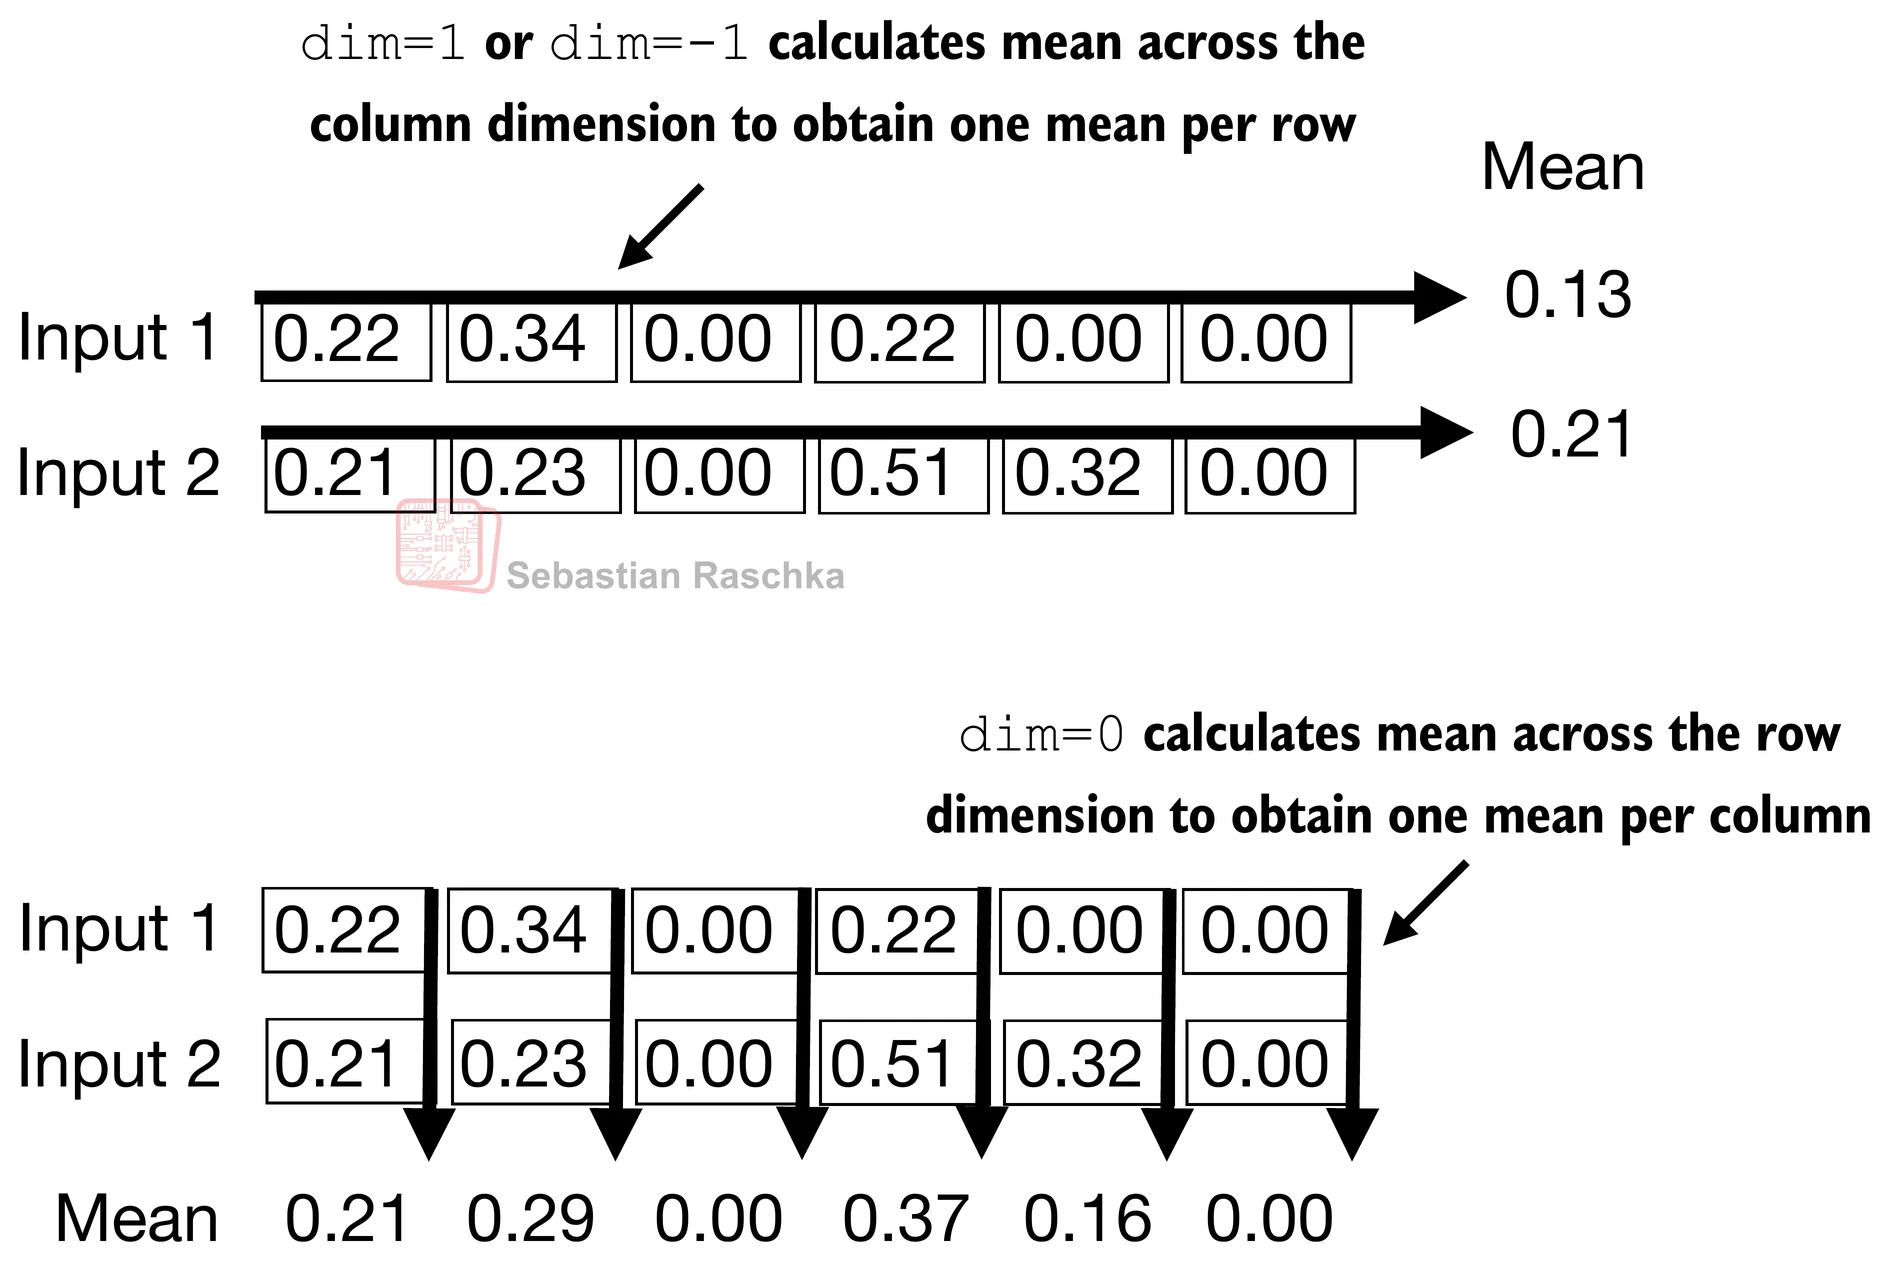

In [6]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out_norm.var(dim=-1, keepdim=True) #variance across features for each sample
print("Normalized output:", out_norm)
print("Mean after normalization:", mean)
print("Variance after normalization:", var)

Normalized output: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean after normalization: tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after normalization: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Using Class with actual batch

In [7]:
from GPT_Model_architecture_class import LayerNorm

ln = LayerNorm(6) #6 features in the input
out_ln = ln(out)

mean = out_ln.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out_ln.var(dim=-1, keepdim=True) #variance across features for each
print("Output after LayerNorm:", out_ln)
print("Mean after LayerNorm:", mean)
print("Variance after LayerNorm:", var)


Output after LayerNorm: tensor([[ 0.6157,  1.4123, -0.8717,  0.5871, -0.8717, -0.8717],
        [-0.0189,  0.1121, -1.0875,  1.5171,  0.5647, -1.0875]],
       grad_fn=<AddBackward0>)
Mean after LayerNorm: tensor([[-1.9868e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after LayerNorm: tensor([[0.9996],
        [0.9997]], grad_fn=<VarBackward0>)


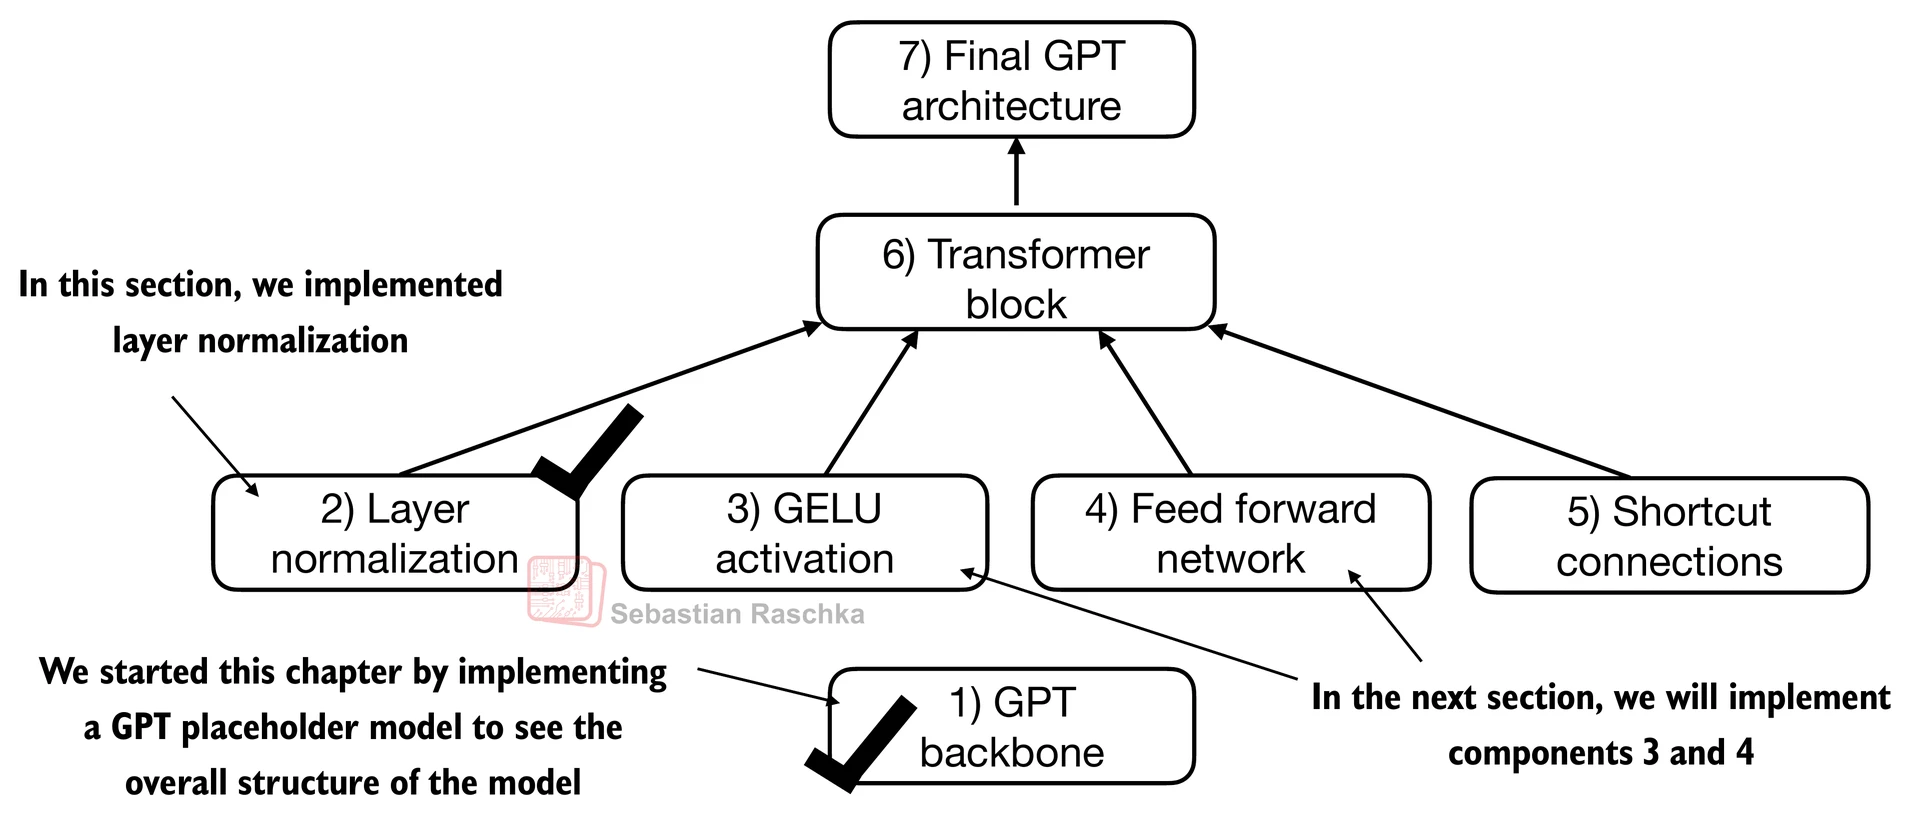

## **Feed forward network with GELU activations**

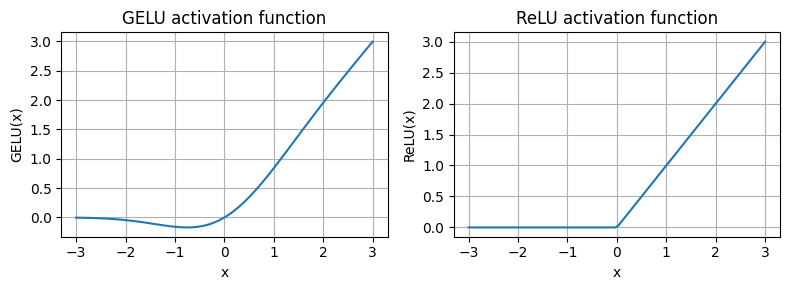
Using GELU instead of Relu allows some negative through helping the model learn more complex patterns 

In [8]:
print(GPT_CONFIG_124M["emb_dim"])

768


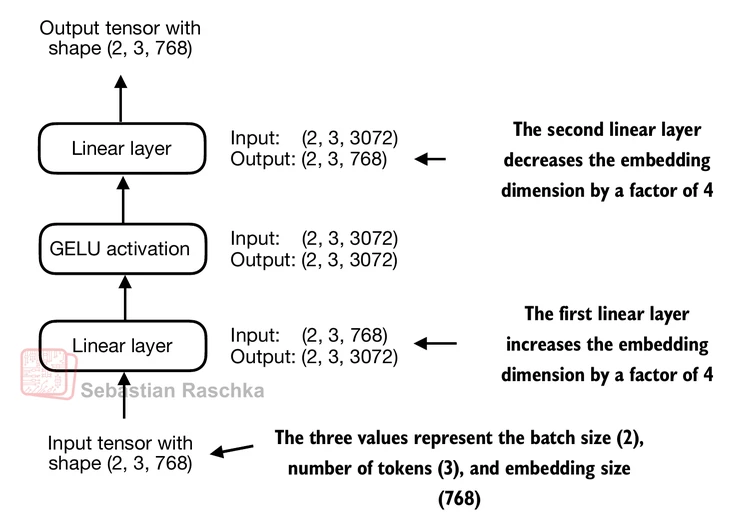

In [9]:
from GPT_Model_architecture_class import FeedForward

ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2,3, 768) #batch of 2 samples, 3 tokens per sample, 768 embedding dimension
out = ffn(x)
print(out.shape) #should be (2,3,768) since we project back to the same dimension

torch.Size([2, 3, 768])


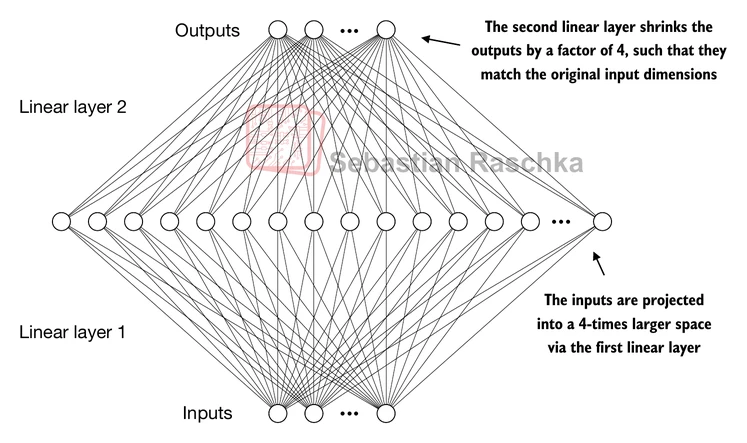
expansion of embedding dimensions internally inside the forward feed allows for richer representation of the layer therefore more learning. each goes thorugh its own linear equation and GELU (more mathematical view points) before shrinking data back down 

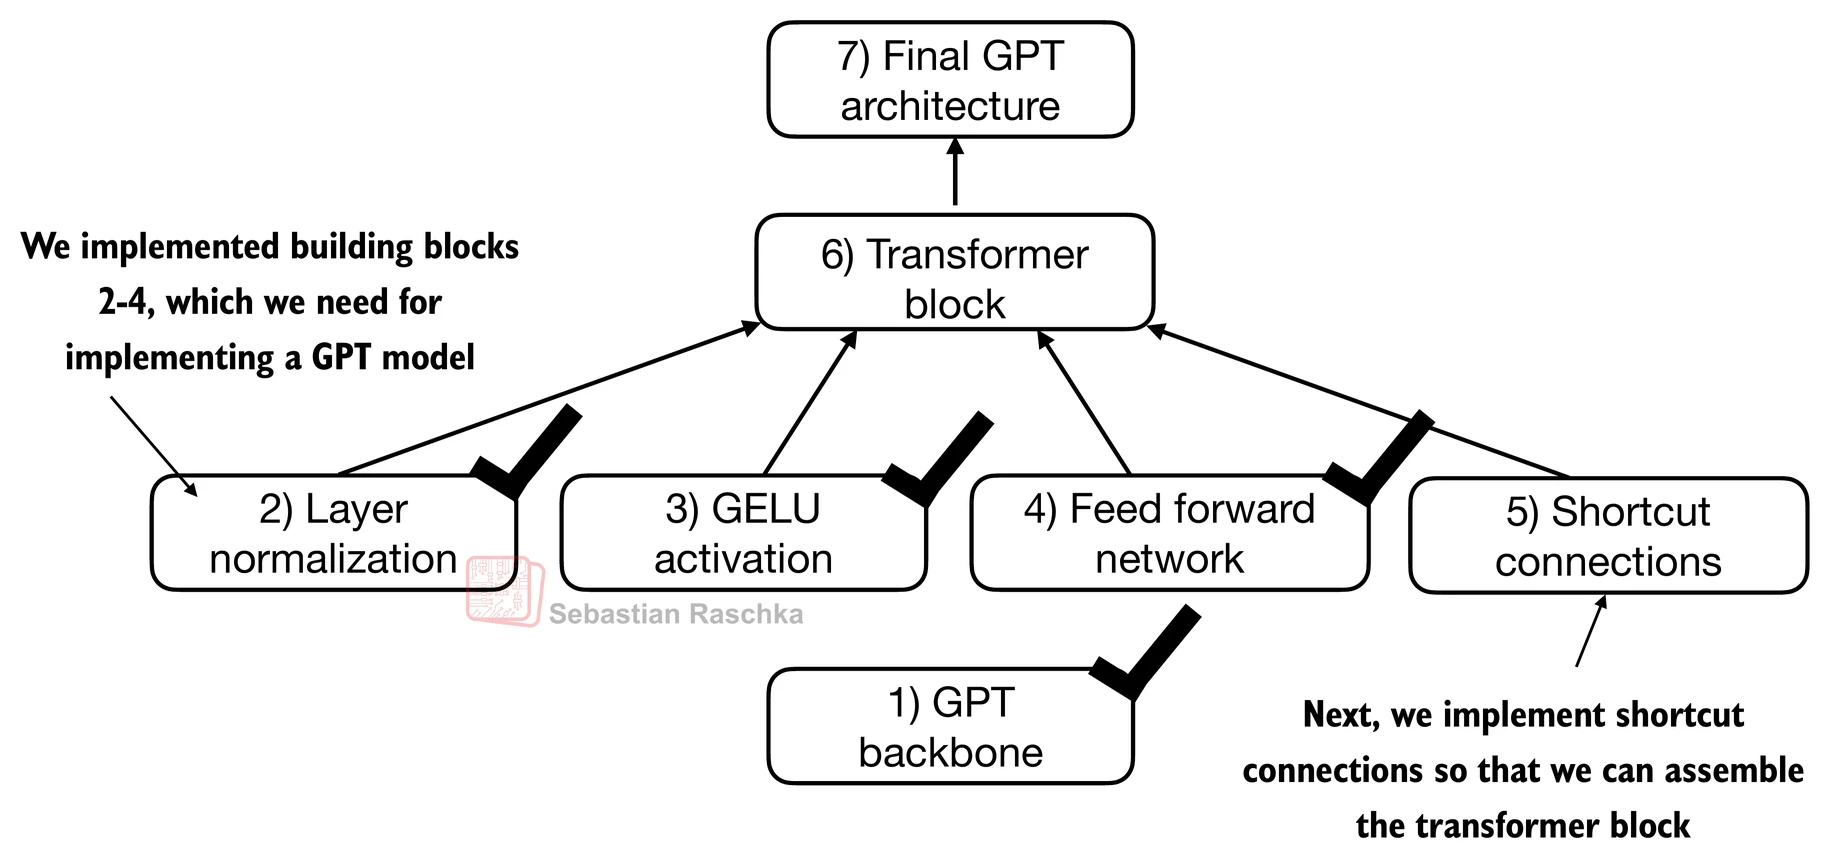

## **Adding Shortcut connections**

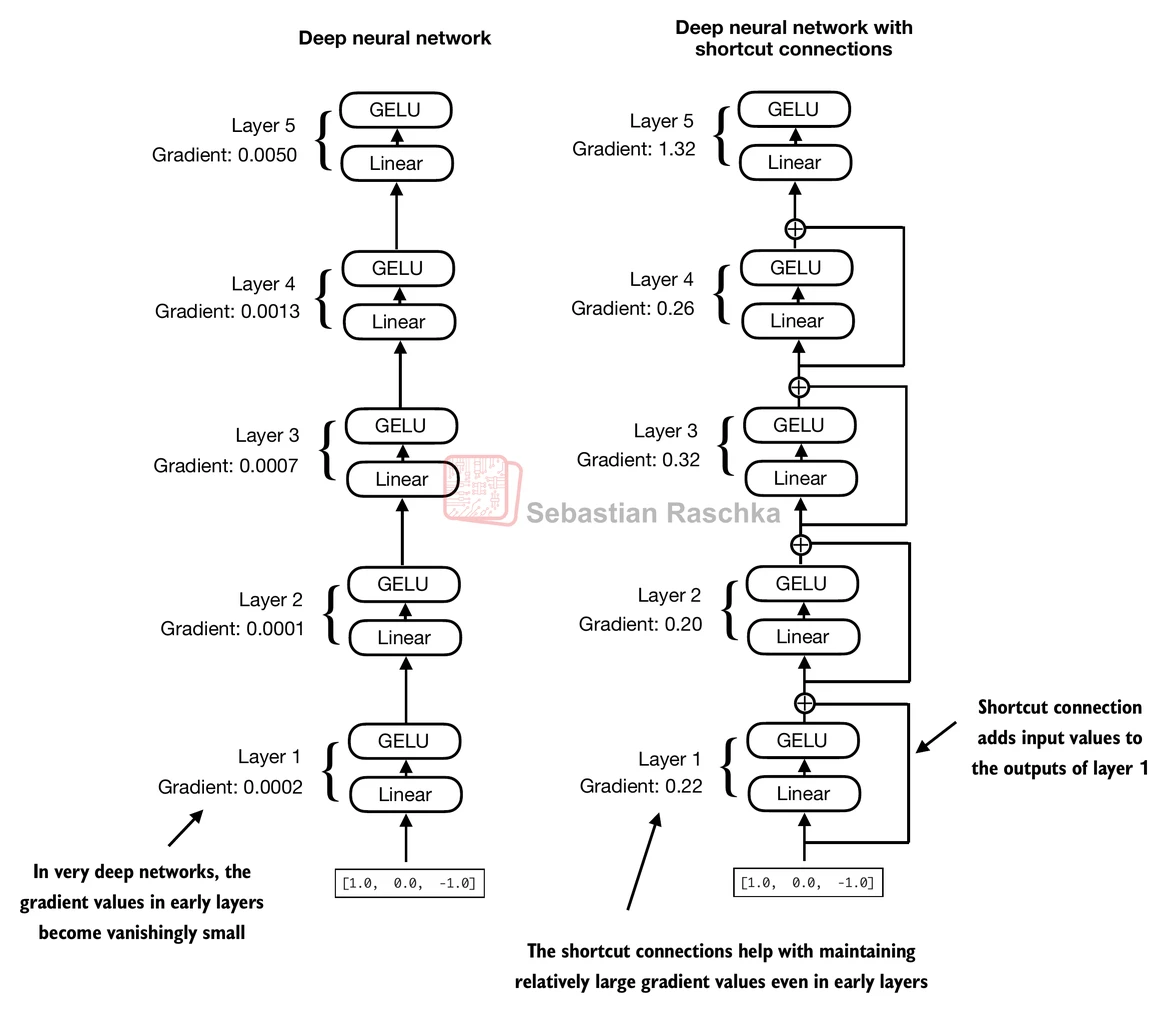

#### Without shortcut

In [10]:
from GPT_Model_architecture_class import ExampleDeepNeuralNetwork, print_gradients

layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1., 0., -1.]])#1 sample, 3 features

torch.manual_seed(123)

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


With this code you can see the first layer gradient is really smalle -> vanishing gradient problem 

#### With Shortcut

In [11]:
torch.manual_seed(123)

model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


last layer does have a higher gradient but the first layer is stablized unlike before 

## **Connecting attention and linear layers in transformer block**

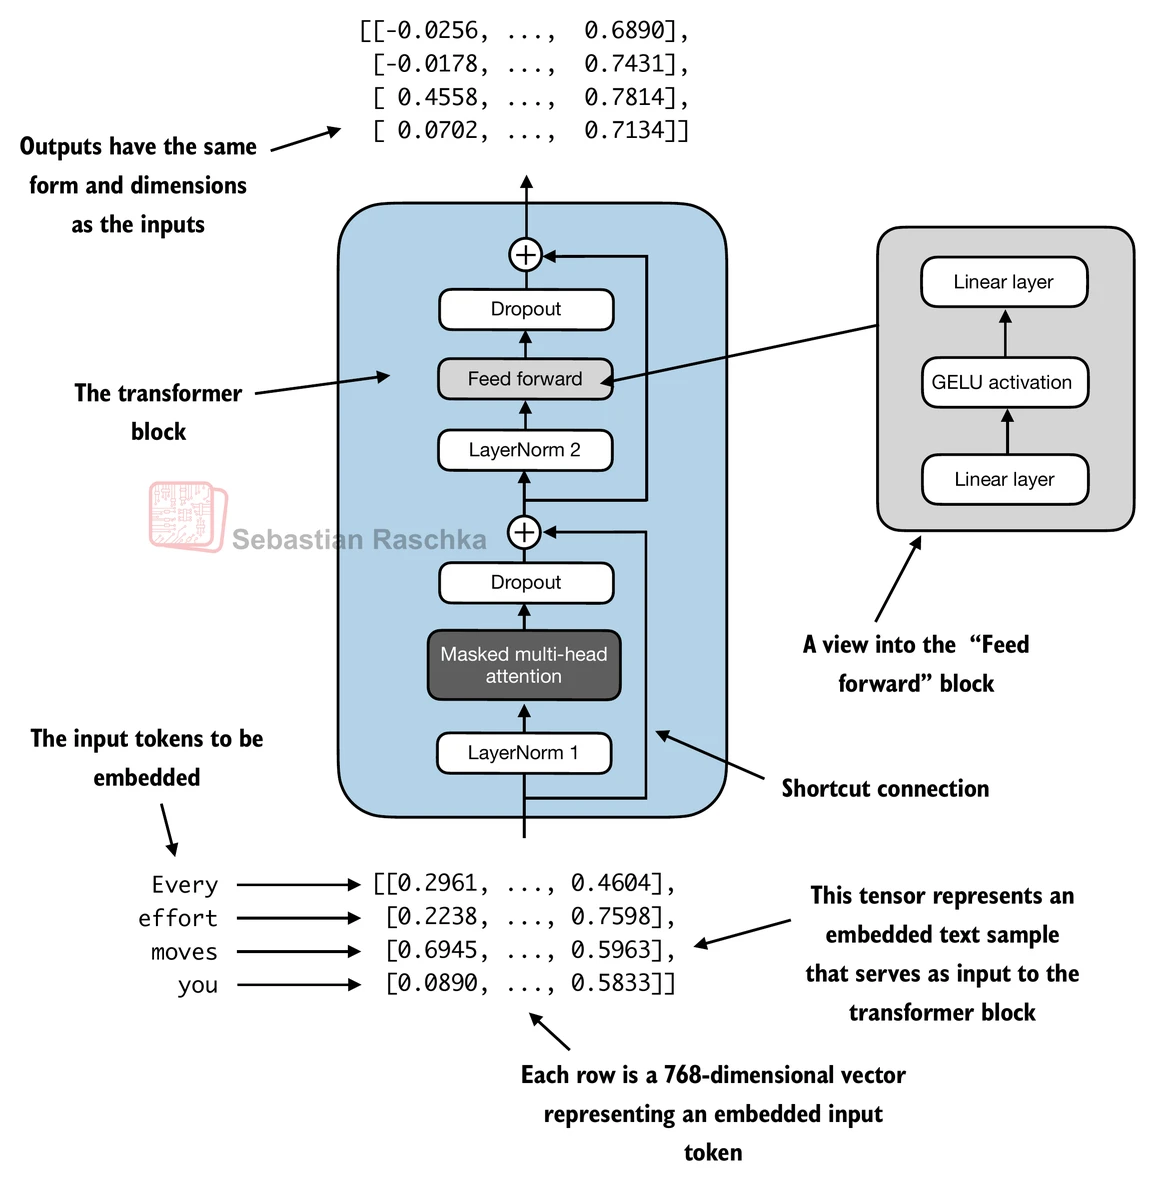

In [12]:
from GPT_Model_architecture_class import TransformerBlock

torch.manual_seed(123)
x = torch.rand(2,4,768)

block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape: ", x.shape)
print("Output shape: ", output.shape)

Input shape:  torch.Size([2, 4, 768])
Output shape:  torch.Size([2, 4, 768])


important to note :
- that the transfomer block maintains a one-to-one relationship between input and output. As the transfomers blocks are combined it means data can pass through and handled directly as the data goes on. 

- while size of vector doesn't change the context of the vector is different. 


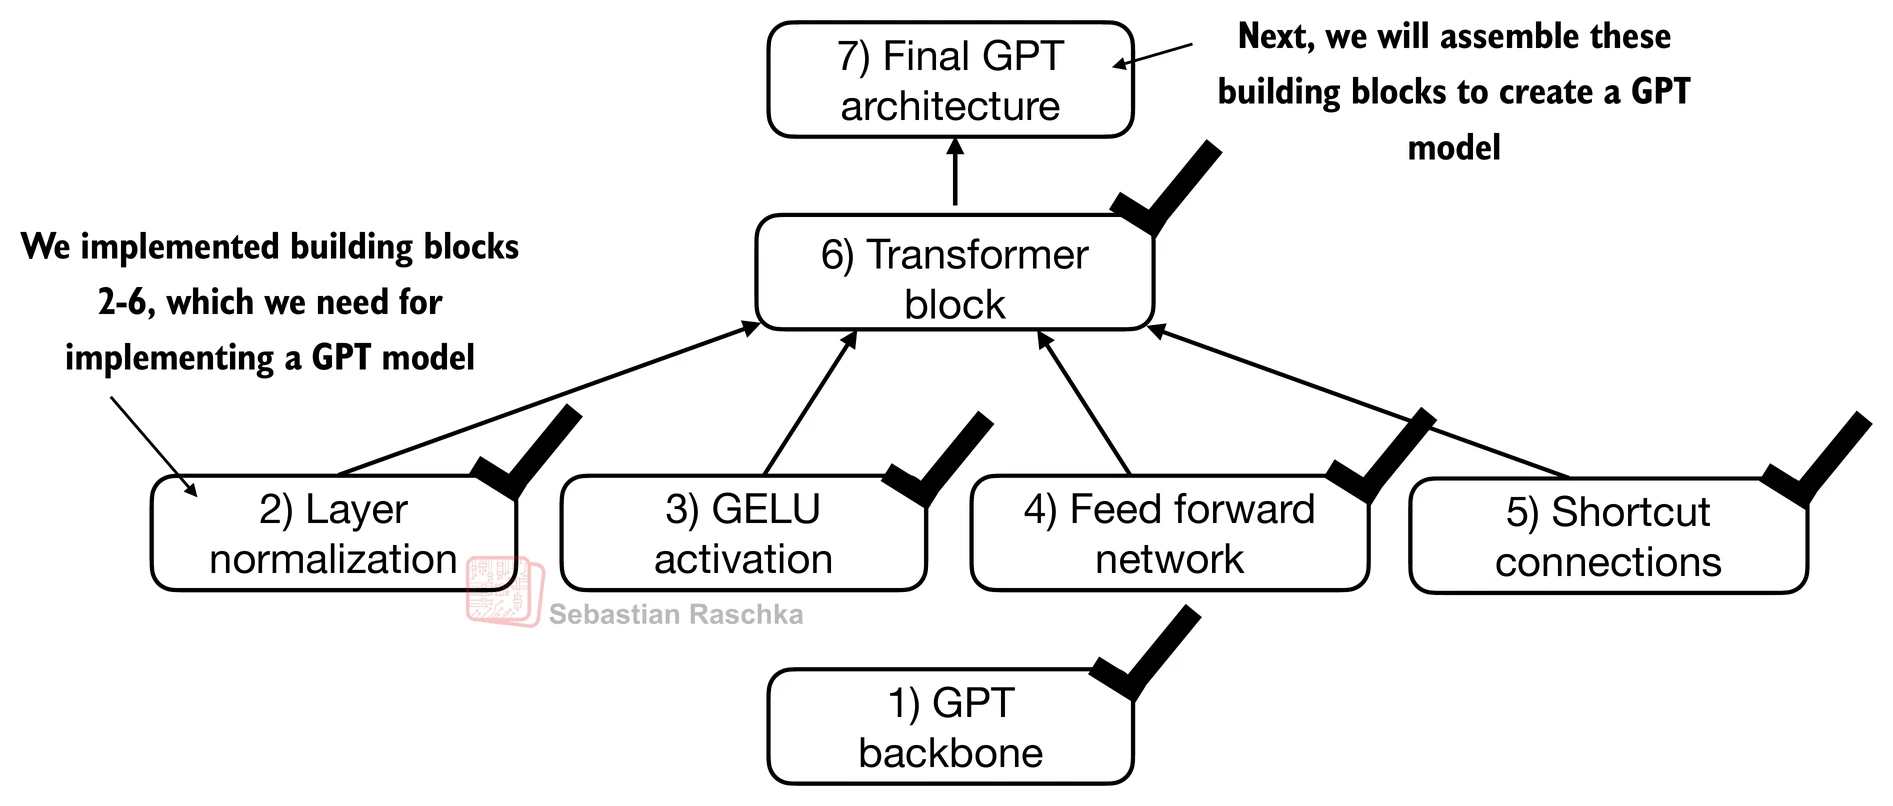

## **Coding GPT model**
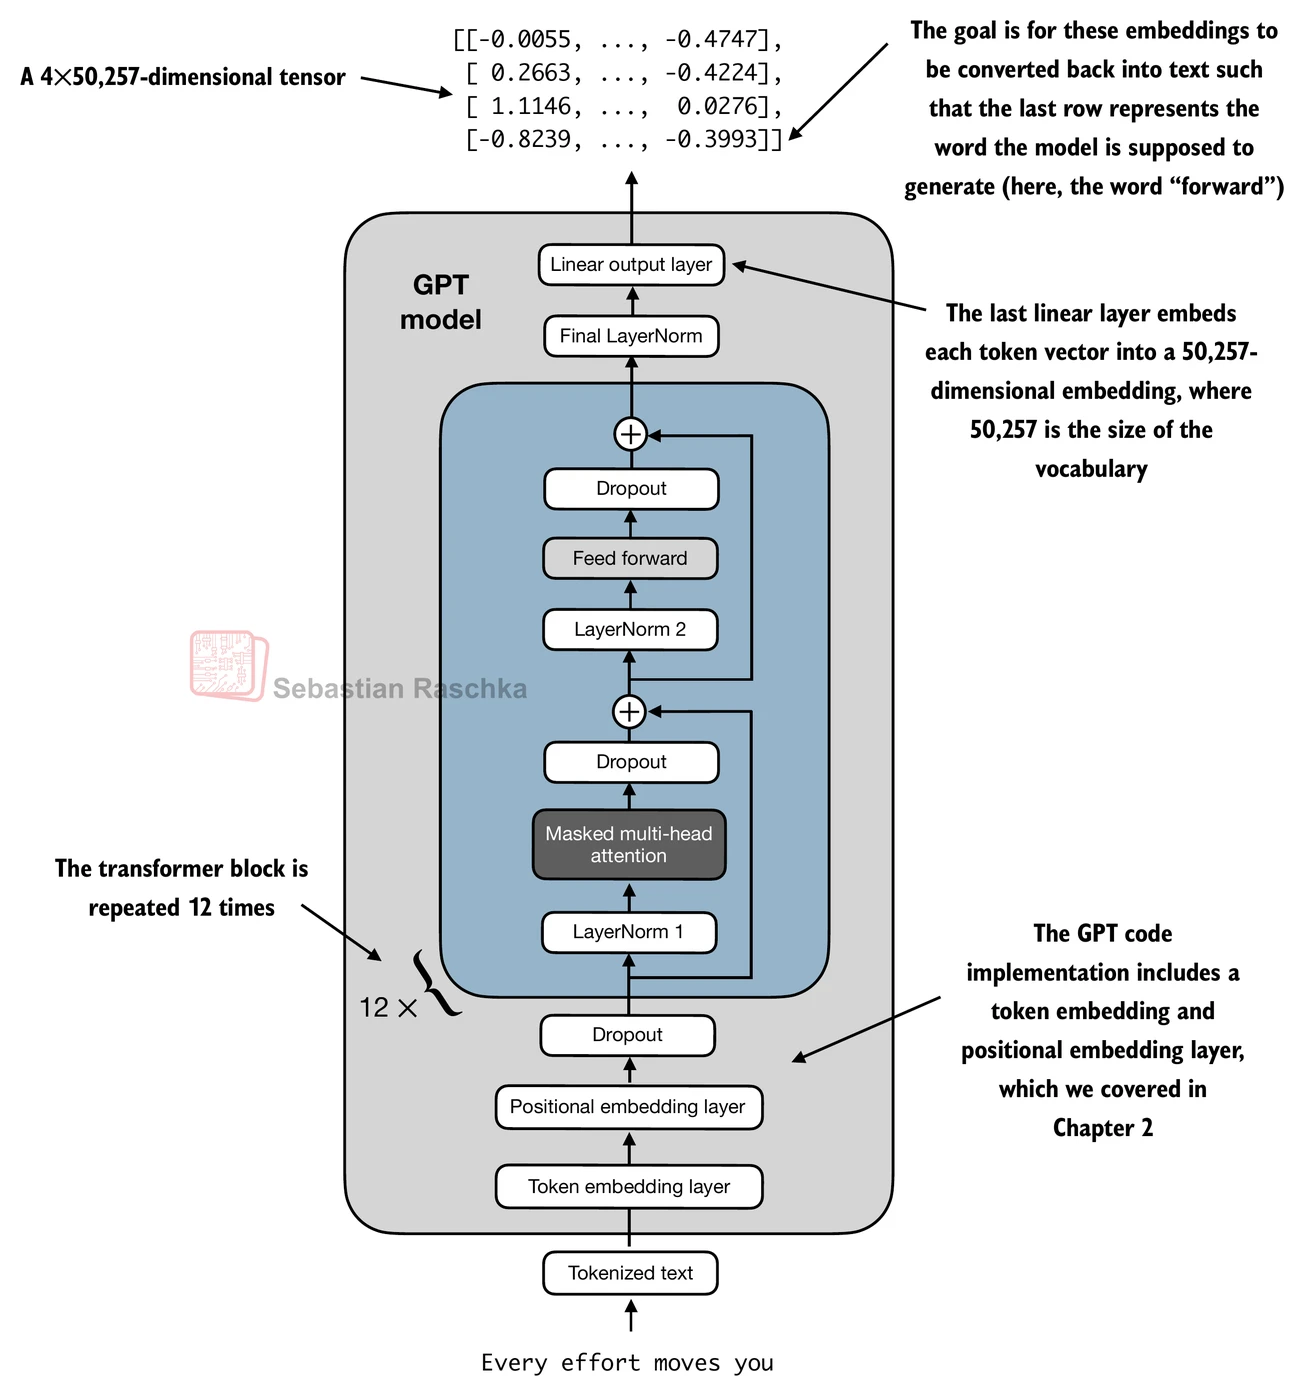



In [13]:
from GPT_Model_architecture_class import GPTModel

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

print("Input batch: ", batch)
print("Output logits shape: ", out.shape)
print(out)

Input batch:  tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output logits shape:  torch.Size([2, 4, 50257])
tensor([[[ 0.3612,  0.4223, -0.0709,  ...,  0.3479,  0.4655, -0.2833],
         [-0.1785, -0.5656, -0.9477,  ...,  0.0476,  0.5173, -0.3160],
         [ 0.7118,  0.0335,  0.1078,  ...,  0.1020, -0.4331, -0.2547],
         [-1.0068,  0.3420, -0.1191,  ...,  0.7193,  0.4018,  0.0532]],

        [[-0.2562,  0.0899,  0.0338,  ...,  0.2659,  0.4448, -0.6800],
         [ 0.1230,  0.3651, -0.2071,  ...,  0.7704,  0.2702,  0.2250],
         [ 1.0555,  1.0312, -0.2797,  ...,  0.6934,  0.3201, -0.3172],
         [-0.1559,  0.3922,  0.3286,  ...,  1.2627, -0.1862,  0.0391]]],
       grad_fn=<UnsafeViewBackward0>)


[2, 4, 50257] 
2 samples inputted each with 4 tokens 

The 50257 represents the vocabulary size of the tokenizer which we will later convert these output vectors back into tokens. 

In [14]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters in the model: ", total_params)

Total parameters in the model:  163009536


*Given that we initialized a 124 million paramter of GPT model why is there 163009536 params?*




In [15]:
print("Token embedding layer shape: ", model.tok_emb.weight.shape)
print("Output layer shape: ", model.out_head.weight.shape)

Token embedding layer shape:  torch.Size([50257, 768])
Output layer shape:  torch.Size([50257, 768])


A size of one of these layer is 50257 x 768 = 38597376 parameters 

Because the current code treats them as 2 separate layers the 38597376 parameters  are applied twice 

**The Solution**
Weight tying, the model reuses the exact same weight matrix for both looking up words at the beginning (input) and predicting words at the very end(output)

1. look up token ID to find 768 dimension embedding vector
2. take final 768 dimension embedding vector and look backwards thorugh same lookup table to find matching token ID. 

In [16]:
total_params_gpt2 = (
    total_params - sum(p.numel()
        for p in model.out_head.parameters()                   
    )
)

print ("Total parameters excluding output layer (GPT-2's parameters): ", total_params_gpt2)

Total parameters excluding output layer (GPT-2's parameters):  124412160


Now we see the 124 million params. 

## **Generate text**

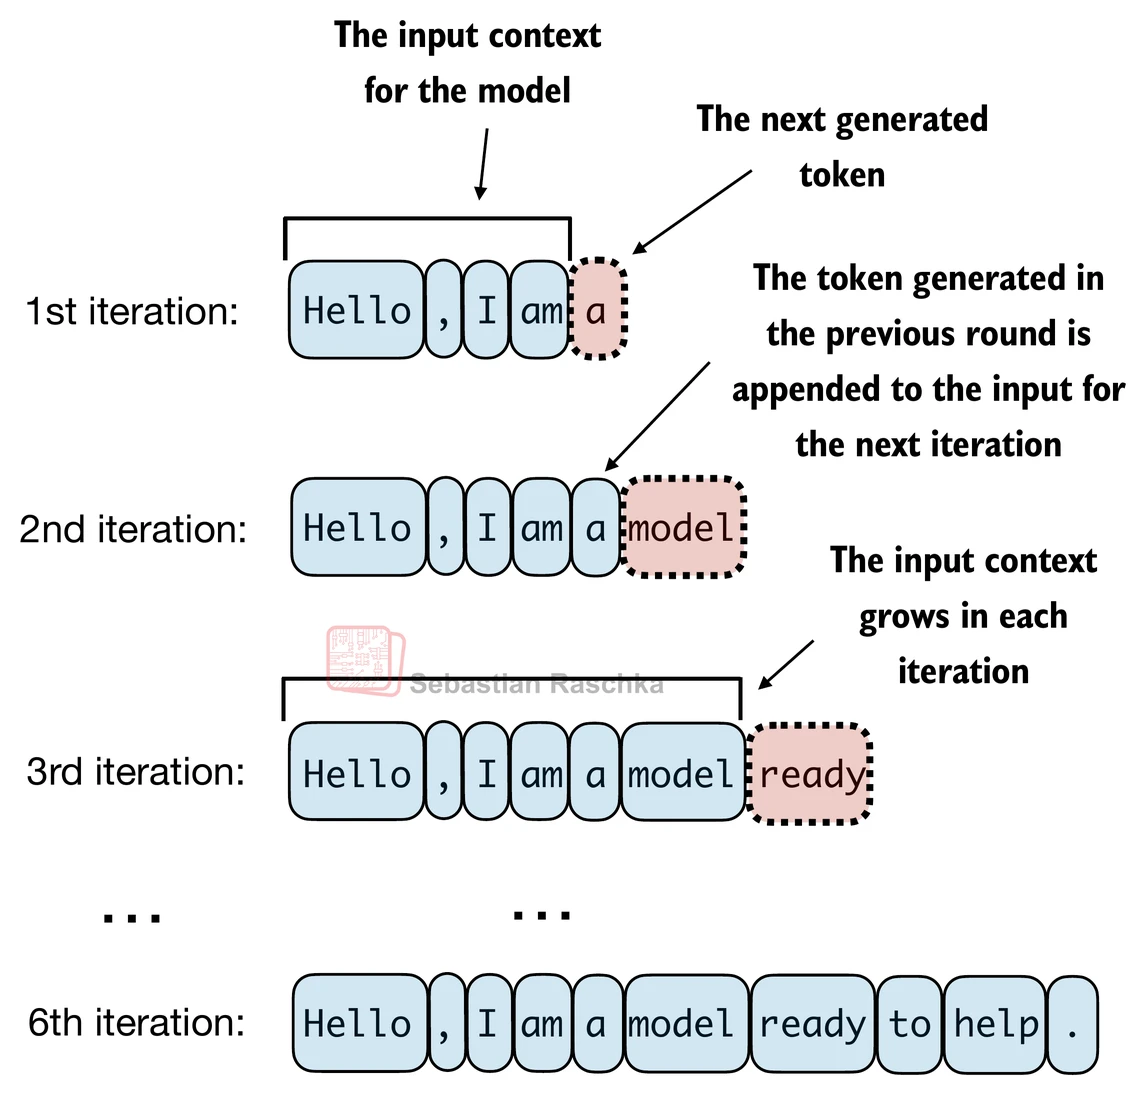

At a high level, LLm generate text regressively. They predict one token at a time and use their previous outputs as inputs for the next step 

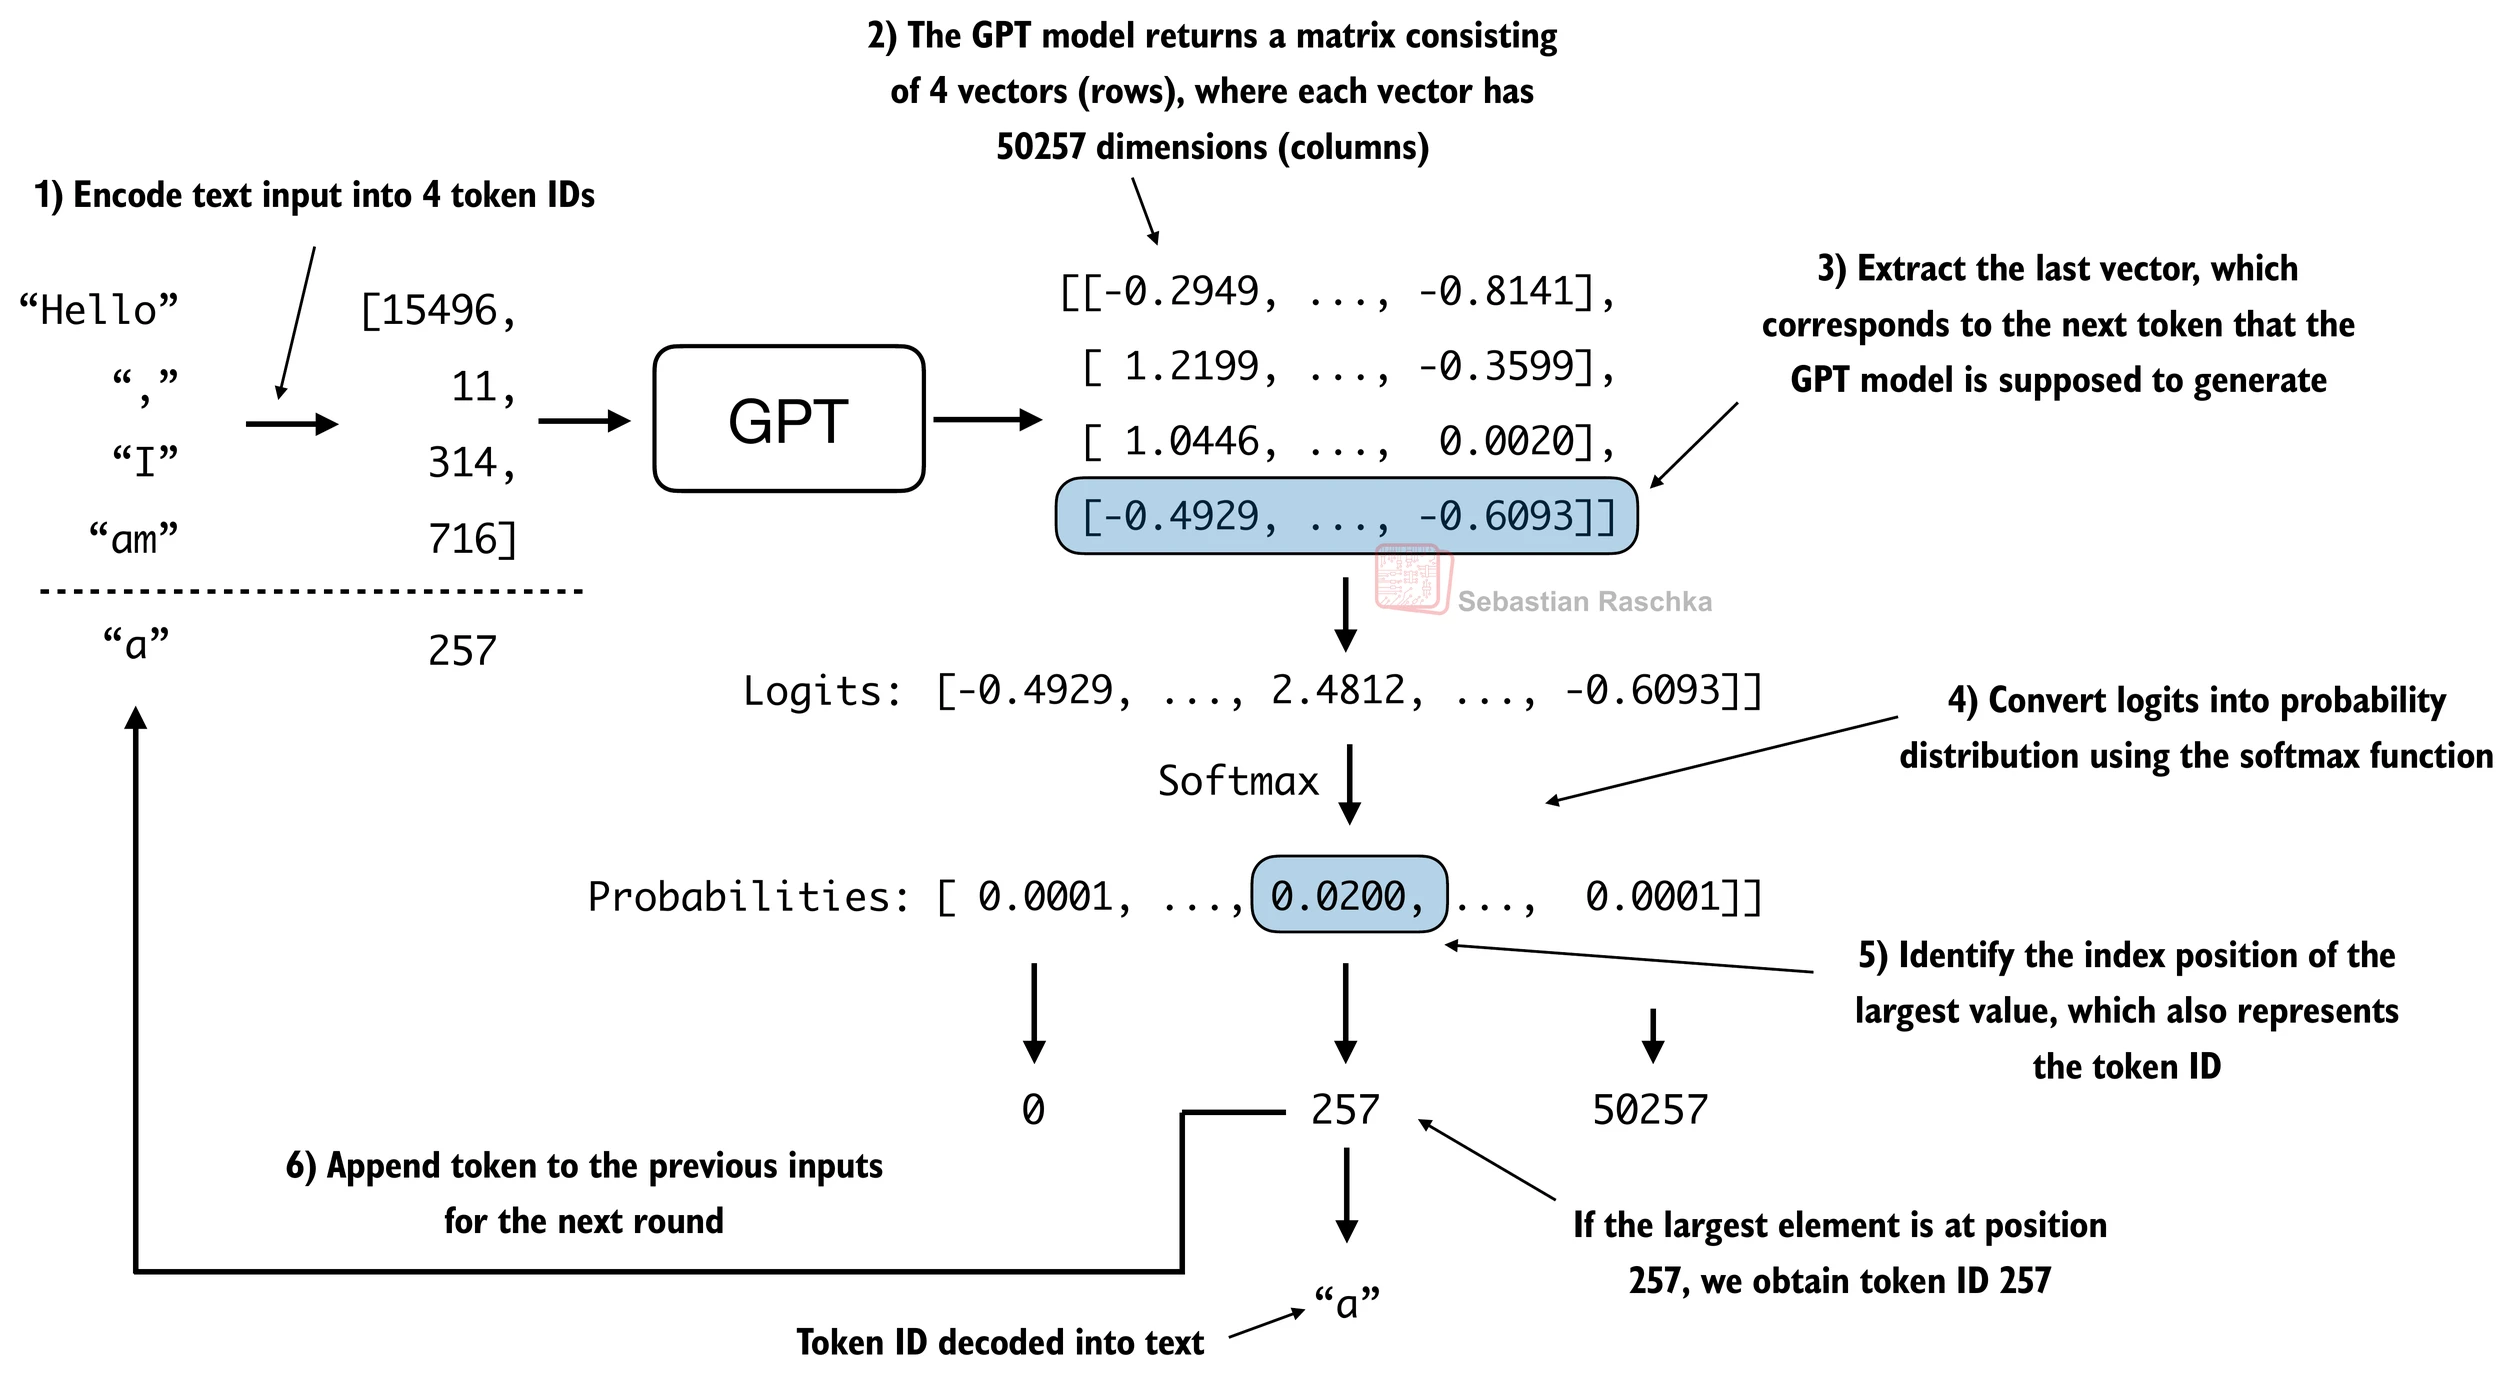


Step 1: Input text tokenized 


Step 2: Forward pass.
 Tokens feed to GPT model (embedding layers and transformer layers) where the output is[batch_size, num_tokens, vocab_size]. For instance, if the model has a vocabulary of 50,257 possible words/tokens, each row in this matrix will contain 50,257 raw numerical scores

Step 3: Extracting last vector
Since the output matrix has a row for every token in the input however we only want the predicted next *unwritten* token we clise tensor to extract last row. This last row represents the raw prediction (logits). 

Step 4: Softmax 
The logits are run through a softmax function that turns the number into a clean probability distirbution where every row has a value between 0->1 and all 50,257 values add up to exactly 1 (or 100%).

Step 5: Selection 
picks the highest probaility as the next token 

Step 6: Decode 
chosen winning token mapped back to readable text through the tokenizer. This token is combined to make the new input of the next word 


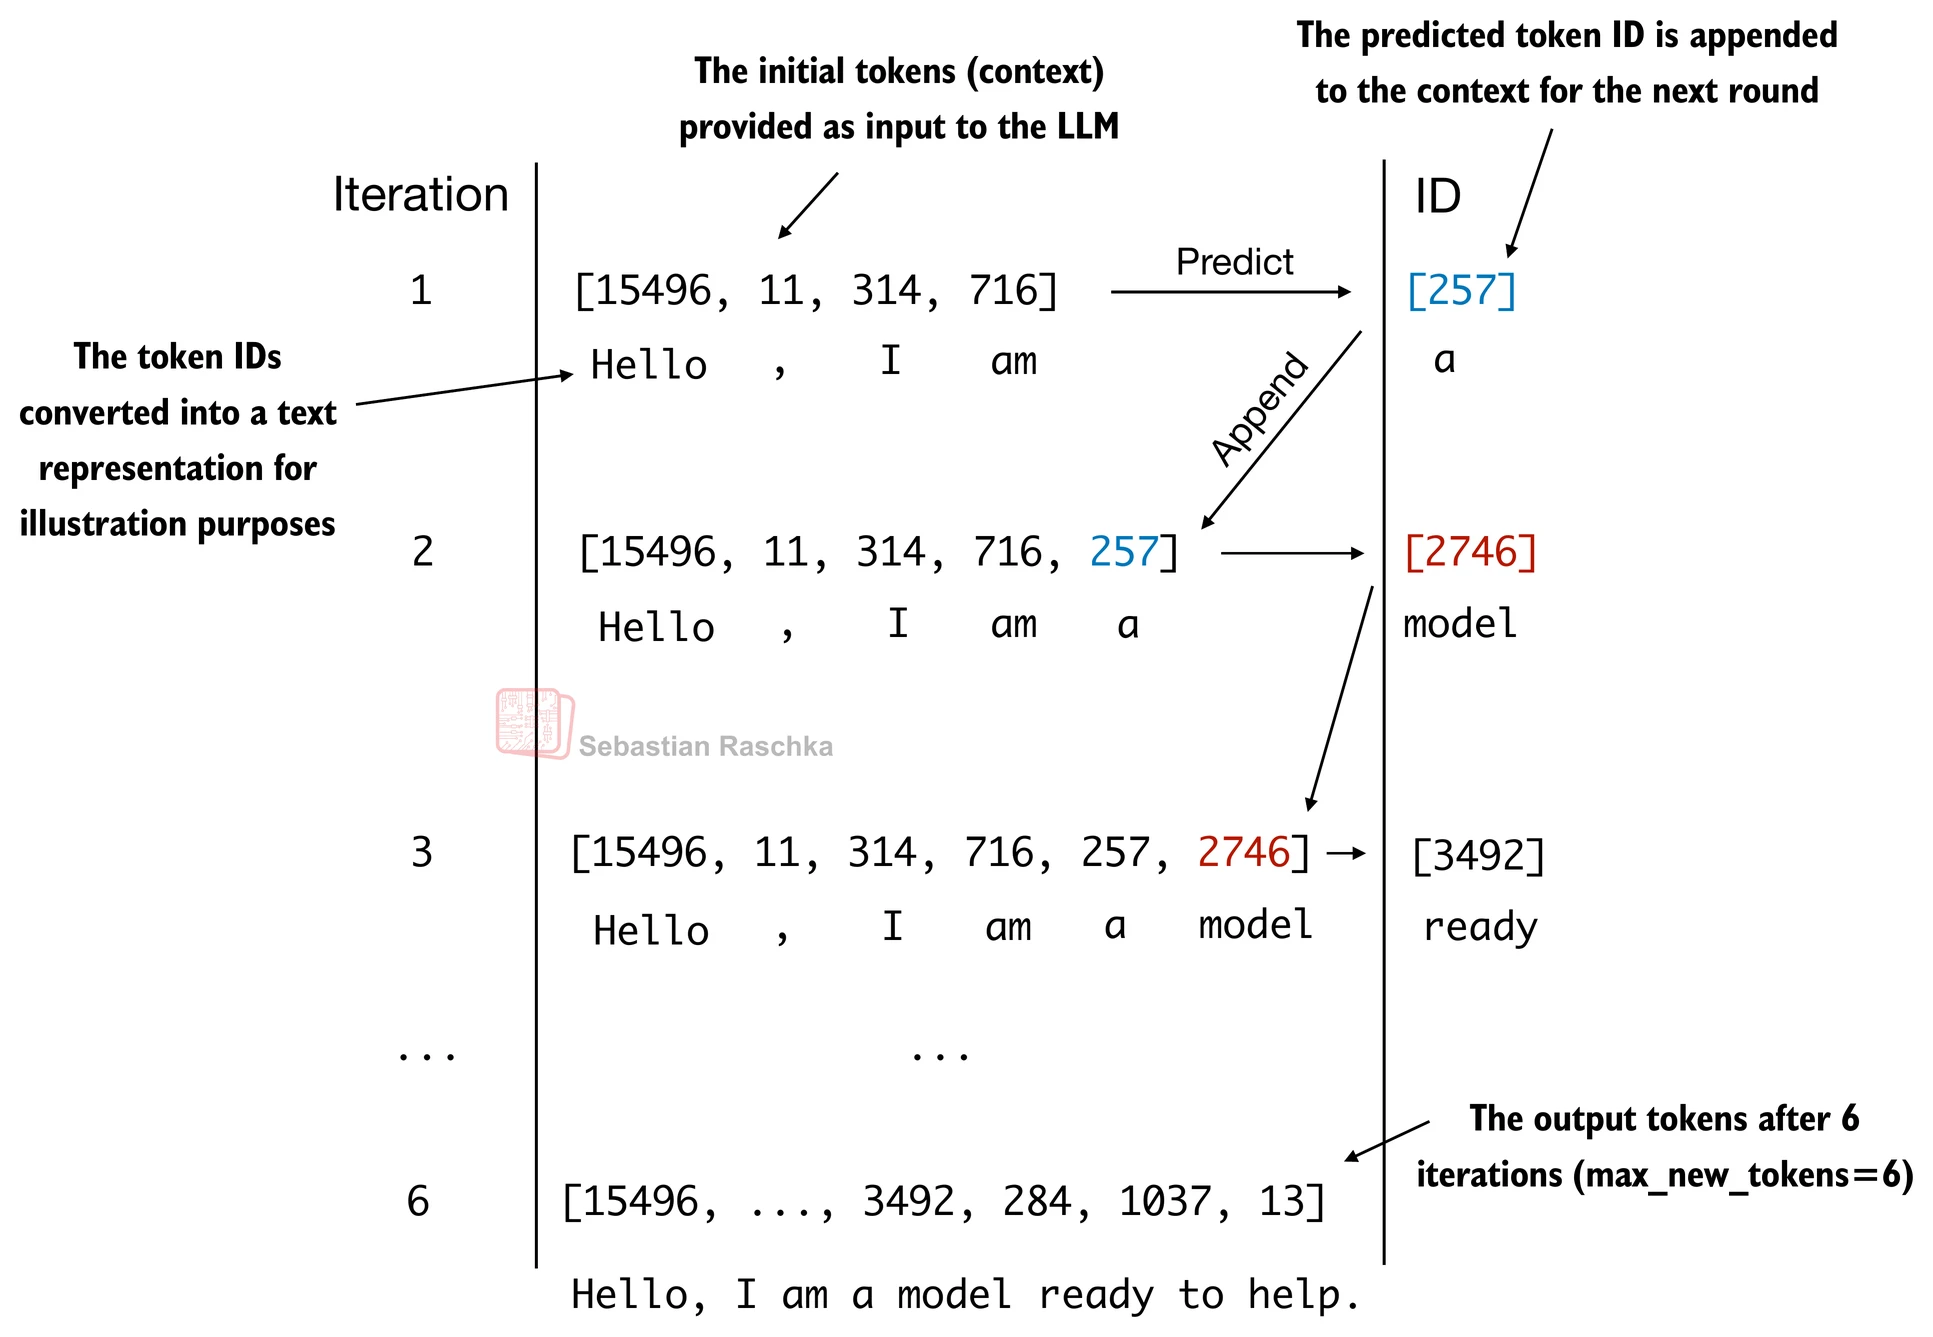

In [17]:
from GPT_Model_architecture_class import generate_text_simple

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("Encoded input: ", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0) #add batch dimension so it matches the expected input shape of (batch_size, seq_length)
print("Encoded tensor shape: ", encoded_tensor.shape)

Encoded input:  [15496, 11, 314, 716]
Encoded tensor shape:  torch.Size([1, 4])


In [18]:
model.eval()#set model to eval mode 

out = generate_text_simple(
    model=model,
    idx = encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output: ",out)
print("Output length: ", len(out[0]))

#the squeeze removes the batch dimension so back to 1D ensor
decoded_text = tokenizer.decode(out.squeeze(0).tolist()) #maps token IDs back to text
print(decoded_text)

Output:  tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length:  10
Hello, I am Featureiman Byeswickattribute argue


The output is wrong because it hasn't been trained yet 